In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [8]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e160a45017', 'id': 'chatcmpl-ECiwJCf4MCXKrLUr1Fhh615ivSNvG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fffb3-a45c-7811-b4de-c48d89573927-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
# from langchain_groq import ChatGroq

# llm_groq=ChatGroq(model="qwen-qwq-32b")
# llm_groq.invoke("Hey I am Soccrates  and i like to play with law")

In [9]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

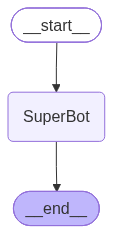

In [28]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [13]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Socretes And I like phylosophy"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f12c520a-62e5-487b-b622-bdcd2e9634f3'),
  AIMessage(content="Hi Krish! It's great to meet someone who enjoys cricket. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 18, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_2fe17714a7', 'id': 'chatcmpl-ECiwL2BLvbQoRsikbOMwamyEyiSjv', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fffb3-ad39-7b13-b1e3-b812dad1bc95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 22, 'to

In [29]:
## Invocation

config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Socretes And I like phylosophy"},config,stream_mode='updates'):
    print(chunk)
    

{'SuperBot': {'messages': [AIMessage(content="Hello, Socretes! It's great to hear that you like philosophy. Philosophy is all about asking big questions and exploring ideas about life, knowledge, and ethics. Whether you're pondering the nature of reality or what it means to live a good life, there's so much to discover. Do you have any favorite philosophical topics or questions you'd like to talk about?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 1365, 'total_tokens': 1436, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_684acb85fd', 'id': 'chatcmpl-ECjCtFqImiye1yA2k9LychJvOiSn7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fffc

In [ ]:
## Invocation

config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Socretes And I like phylosophy"},config,stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Socretes And I like phylosophy', additional_kwargs={}, response_metadata={}, id='861d5226-4de9-478a-ad85-30c9f7c524cb'), AIMessage(content="Hello, Socrates! It's great to meet someone with an interest in philosophy. Socrates, the ancient philosopher, emphasized the importance of questioning and dialogue in the pursuit of knowledge. Do you have any particular philosophical topics or questions you're interested in discussing?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 22, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_684acb85fd', 'id': 'chatcmpl-ECj3RGo1atMOFKfhw5mIoY5cdLo8j', 'service_tier': 'default',

In [30]:
## Invocation

config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Introduce Socretes to small child"},config,stream_mode='values'):
    # print(chunk)
    for mm in chunk['messages']:
        print("--",mm)

-- content='Hi,My name is Socretes And I like phylosophy' additional_kwargs={} response_metadata={} id='861d5226-4de9-478a-ad85-30c9f7c524cb'
-- content="Hello, Socrates! It's great to meet someone with an interest in philosophy. Socrates, the ancient philosopher, emphasized the importance of questioning and dialogue in the pursuit of knowledge. Do you have any particular philosophical topics or questions you're interested in discussing?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 22, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_684acb85fd', 'id': 'chatcmpl-ECj3RGo1atMOFKfhw5mIoY5cdLo8j', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': 